# 08 - Consistency Models / LCM（1 步生成的圣杯）

> **一句话直觉**：训一个"瞬移函数"$f(x_t, t) \to x_0$，不管你在轨迹的哪个时刻都能**一步跳到终点**。

**类比 — 下山路**：
- **Diffusion / Flow Matching**：从山顶一步一步走下山，每步判断方向
- **Consistency Models**：训练时你站在山上任何位置都能**直接指着山脚的小镇**——推理时不管在哪一步，1 步到位

**为什么极重要（2024-2026 工业主流）**：
- **LCM**（Latent Consistency Model）让 SDXL **4 步出图**，ComfyUI 社区火爆
- **SDXL-Turbo / SD3-Turbo / FLUX-Schnell** 等少步模型都受 CM 思想启发（具体技术是对抗蒸馏一系，见 Part 4/5 的谱系澄清）
- **实时数字人、视频生成**必经之路：50 步 → 1 步是 50 倍加速，是从"离线"到"实时"的分水岭

**符号约定**：沿用 06/07 的 FM 符号——$x_0$ 纯噪声、$x_1$ 真实数据、$t\in[0,1]$。本课新增：$f_\theta$ 瞬移函数（学生）、$f_{\theta^-}$ EMA 影子网络、$F_\theta$ 网络原始输出。

> ⚠️ **方向警告**：本课代码沿用 06/07 约定，**$t=0$ 是噪声、$t=1$ 是数据**。但 CM 原论文（Song et al. 2023）是 diffusion 约定——$t$ 越大越噪、数据在 $t\approx 0$ 端。读论文和读本课代码时刻提醒自己在哪套坐标系里。

## Part 0 — 从"轨迹"到"一致性"的视角跃迁

前面 Diffusion/FM 学的是**速度场** $v_\theta(x_t, t)$：告诉你**下一瞬间怎么动**。
Consistency Models 学的是**瞬移函数** $f_\theta(x_t, t) \to x_0$：直接告诉你**终点在哪**。

这个跃迁有点像物理里从"微分方程"到"解析解"——能一步跳过去的话，谁想一步步积分。

**关键概念**：轨迹上所有点的"终点预测"必须**一致**（consistency）。

给定一条 ODE 轨迹 $\{x_t : t \in [0, 1]\}$，对**任意** $s, t$：
$$
f_\theta(x_t, t) = f_\theta(x_s, s) = x_0
$$

这就是 **Consistency Property**。训练就是让模型在同一条轨迹上，对任何时刻都输出同一个终点预测。

> 注意：Part 0-2 的公式沿用 **CM 论文记号**——$x_0$ 指**数据**（论文里 $t$ 越大越噪）。到 Part 6 代码我们切回 06/07 的 FM 约定（数据是 $x_1$），瞬移函数相应变成 $f(x_t, t) \to x_1$。切换处会再次提醒。

## Part 1 — 训练目标（面试必考）

### 核心 loss：**Consistency Distillation (CD)**

需要一个预训好的**教师 Diffusion 模型**。训练过程：

1. 采样真实数据 $x_0$，加噪得到 $x_{t+\Delta t}$
2. 用教师走**一小步** ODE，得到 $x_t$（更靠近 $x_0$）
3. **约束**：学生网络对这一对相邻点 $(x_{t+\Delta t}, x_t)$ 的预测要一致

$$
\boxed{\; \mathcal{L}_{CD} = \mathbb{E} \Big[ d\big( f_\theta(x_{t+\Delta t}, t+\Delta t),\; f_{\theta^-}(x_t, t) \big) \Big] \;}
$$

**符号点名**：
- $d$：距离度量——玩具数据用 L2，图像用 LPIPS
- $f_{\theta^-}$：EMA 影子网络——只出"标准答案"，**不回传梯度**（防止塌缩，类似 RL 里的 target network）
- 两个输入 $x_{t+\Delta t}$ 和 $x_t$ 是**同一条 ODE 轨迹上的相邻点**——"同一条"三个字是这个方法的命门，教师就是用来保证这一点的

**直觉**：相邻时刻的预测相等 → 递推下去所有时刻预测都相等 → 所有点都映射到同一个终点。

### Consistency Training (CT)
不需要教师模型，直接在真实数据上训。效果略差但更独立，理论价值高。

## Part 2 — 边界条件和参数化（易忘点）

Consistency Models 的一个关键工程技巧：**边界条件**。

核心原则一句话：**恒等映射必须锚在数据端**——"已经在终点了还跳什么"。论文记号下数据在 $t\to 0$ 端，所以要求 $f(x_0, 0) = x_0$。直接让网络满足这个约束很难，所以用一个**巧妙的参数化**：

$$
f_\theta(x, t) = c_{skip}(t) \cdot x + c_{out}(t) \cdot F_\theta(x, t)
$$

- $c_{skip}(t)$ 和 $c_{out}(t)$ 是**人工设计的系数**，在**数据端** $c_{skip}=1, c_{out}=0$
- $F_\theta$ 是神经网络的原始输出
- 数据端 $f = 1 \cdot x + 0 \cdot F = x$，边界条件自动满足 ✓

**极端值代入检查（按本课 Part 6 代码的 FM 约定：$t=1$ 是数据）**：

- **数据端 $t=1$**：$c_{skip}=1, c_{out}=0$ → $f(x, 1) = x$ ✓ 原地不动
- **噪声端 $t=0$**：$c_{skip}=0, c_{out}=1$ → $f(x, 0) = F_\theta(x, 0)$，全靠网络一步跳到数据
- **中间 $t$**：两者线性混合

这个代入是**白板必做动作**——做了就不可能把 $c_{skip}/c_{out}$ 的方向写反（本课代码曾经就是没做这个检查，把恒等锚错写到了噪声端，一步生成直接崩掉，实验修过才对）。

**面试重点**：这不是小细节，是 CM 能训练稳定的关键。LCM 论文也保留了这个参数化。

## Part 3 — LCM：把 CM 搬到 Latent 空间（工程爆款）

**LCM (Latent Consistency Model, 2023)** 做了两件事：
1. **在 Stable Diffusion 的 latent space 上训 CM**（不是 pixel space）
2. **用 LCM-LoRA** 让任何 SDXL 模型 4 行代码变 4 步模型

### LCM 的两个核心技术改动（面试真正该答的）

**1. Skipping-step：一致性对不再取相邻步，而是相隔 $k$ 步**

原版 CD 约束的是相邻两步（$t$ 和 $t+\Delta t$）。在 latent diffusion 的上千步离散化里，相邻步太近，两边预测几乎一样，**loss 太小学不动**。LCM 改成约束相隔 $k$ 步（如 $k=20$）的点对——把差距拉开，loss 有梯度信号，收敛快得多。

**2. CFG 嵌入蒸馏：把 guidance scale $w$ 烧进权重**

教师推理时要做 CFG（一次条件 + 一次无条件，两倍前向）。LCM 把 $w$ 作为**条件输入**喂给学生网络，对"增广后的 CFG ODE 求解器"做蒸馏。结果：学生一次前向就等价于教师的 CFG 输出——**推理省一半前向**，而且 $w$ 可以在推理时连续调。

### LCM-LoRA 工程细节
- 不重训整个 UNet，只训一个 LoRA
- 加载到 SDXL / RealVisXL / Juggernaut 等模型都能用
- ComfyUI 的 "4-step turbo" 就是它
- **推理延迟从 10 秒降到 0.5 秒**，实时生成变现实

### 工业落地场景
| 场景 | 用 LCM 前 | 用 LCM 后 |
|------|----------|----------|
| 实时数字人面部生成 | 离线批处理 | 实时流式推理 |
| AI 游戏素材生成 | 等 10s 出图 | 点一下出 |
| 视频生成 | 每帧 30s | 30 FPS |

## Part 4 — 一步生成技术家族（2024-2025 全景）

Consistency Models 只是一个开端，**一步生成**已经是激烈竞争的主战场。

**怎么读这张表**：精读前两行（CD / LCM，本课主角）和 DMD 行（下一节主角），其余扫一眼名字、知道谱系归属即可。

| 方法 | 核心思想 | 步数 | 备注 |
|------|----------|------|------|
| **Consistency Distillation** | 相邻时刻预测一致 | 1-4 | 质量比教师有可感知差距 |
| **LCM** | CD 搬到 latent + skipping-step + CFG 嵌入 | 4 | 细节丢失 |
| **ADD / LADD（对抗蒸馏）** | GAN 判别器 + 蒸馏混合 loss | 1-4 | **SDXL-Turbo / SD3-Turbo / SDXL-Lightning / FLUX-schnell 一系**；多样性下降 |
| **DMD / DMD2** | **分布匹配**而非轨迹匹配 | 1 | 独立路线，训练复杂 |
| **Shortcut Models**（选读） | 网络额外吃"步长"条件，自蒸馏出大步跳跃 | 1-4 | 2024.10 |
| **Mean Flow**（选读） | 学"平均速度"而非"瞬时速度" | 1 | 2025.05，与 Shortcut 同方向、更晚出 |
| **Rectified Flow + Distill** | 先拉直再蒸馏 | 1-2 | InstaFlow 路线 |

**谱系澄清（面试口径，别答反）**：**ADD/LADD（对抗蒸馏）是 Turbo / Lightning / schnell 一系；DMD 是另一条独立路线（分布匹配）**。两者都受 CM"少步生成"启发，但技术内核不同。

**当前工业默认选型（2026）**：
- 追求质量：**Flow Matching + DiT**（50 步），SD3/FLUX 路线
- 追求部署：**对抗蒸馏（ADD/LADD）或 DMD** 蒸到 1-4 步
- 混合：先 FM 训好，再蒸出少步版本，两个都发布

## Part 5 — DMD：工业界的新宠（独立展开）

**DMD (Distribution Matching Distillation, Yin et al. 2024)** 是当前工业一步生成的两条主流路线之一（另一条是 ADD/LADD 对抗蒸馏，见 Part 4 谱系）。

### 核心区别 vs CM
| 维度 | Consistency Models | DMD |
|------|--------------------|----|
| 蒸馏目标 | 轨迹匹配（点对点） | **分布匹配**（整体） |
| 需要的信号 | 教师的 ODE 轨迹 | 教师的 score function |
| 一步质量 | 与教师有可感知差距（具体数字随任务而异） | 与教师接近 |

### DMD 的 loss 粗框架
用两个 score function 的散度作为 loss：
- $s_{real}(x, t)$：真实分布的 score（来自教师）
- $s_{fake}(x, t)$：学生当前生成分布的 score（训练一个辅助网络学）

$$
\mathcal{L}_{DMD} = \mathbb{E}_t \big[ \text{KL}(p_{fake} \| p_{real}) \text{ 的近似} \big]
$$

**直觉**：不管学生是不是沿着同一条路径走，只要最终生成的分布像教师就行。这个放松让学生找更短的路径。

### 落地成果与谱系（别记混）
- **DMD 一系**：DMD / DMD2（MIT + Adobe），代表作是 1 步 SDXL 蒸馏
- **对抗蒸馏一系（不是 DMD）**：SDXL-Turbo（ADD）、SD3-Turbo（LADD）、SDXL-Lightning（渐进对抗蒸馏）、FLUX-schnell

**面试加分句**：2024-2025 工业一步生成，CM 是入门理解，**对抗蒸馏（ADD/LADD）和 DMD 是两条并行的落地主流**。

## Part 6 — 代码：极简 Consistency Model 训练骨架（面试必看）

不跑完整 Image Diffusion（太慢），只在 2D 玩具数据上演示 CM 的训练 loop。重点看 loss 写法。

> 📌 **约定切换声明（写代码前先立坐标系）**
> CM 论文（Song et al.）里 $t\to 0$ 是**数据**、$t$ 大是噪声；我们的代码沿用 06/07 的 **FM 约定：$t=1$ 是数据、$t=0$ 是噪声**。
> 对照翻译：论文的边界条件 $f(x, \epsilon) = x$（数据端恒等），在我们这里就是 $f(x, 1) = x$，所以 **$c_{skip}(1) = 1$、$c_{out}(1) = 0$**；瞬移函数从"预测 $x_0$"变成"预测 $x_1$"。
> 下面每个系数写完都做一次 Part 2 的极端值代入检查。

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
torch.manual_seed(0)

# ===== 2D 环形数据 =====
def sample_data(n):
    th = torch.rand(n) * 2 * torch.pi
    r = 2.0 + 0.1 * torch.randn(n)
    return torch.stack([r*torch.cos(th), r*torch.sin(th)], 1)

data = sample_data(1000)

# ===== 先训一个 FM 教师（简化版）=====
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.f = nn.Sequential(nn.Linear(3,64), nn.SiLU(),
                               nn.Linear(64,64), nn.SiLU(), nn.Linear(64,2))
    def forward(self, x, t):
        if t.ndim == 0: t = t.expand(x.shape[0])
        return self.f(torch.cat([x, t.unsqueeze(-1)], -1))

teacher = Net()
opt = torch.optim.Adam(teacher.parameters(), 1e-3)
for _ in range(2000):
    idx = torch.randperm(1000)[:256]
    x1 = data[idx]; x0 = torch.randn_like(x1)
    t = torch.rand(256)
    xt = (1-t).unsqueeze(-1)*x0 + t.unsqueeze(-1)*x1
    loss = ((teacher(xt, t) - (x1 - x0))**2).mean()
    opt.zero_grad(); loss.backward(); opt.step()
print('teacher trained')

teacher trained


In [2]:
# ===== 定义学生 Consistency Model，含边界条件参数化 =====
# FM 约定：t=0 噪声，t=1 数据。恒等映射必须锚在数据端 t=1。
class ConsistencyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.F = Net()

    def c_skip(self, t):
        # 数据端 t=1: c_skip=1（原地不动）；噪声端 t=0: c_skip=0
        return t

    def c_out(self, t):
        # 数据端 t=1: c_out=0；噪声端 t=0: c_out=1（全靠网络一步跳到数据）
        return 1.0 - t

    def forward(self, x, t):
        '''f_theta(x, t) -> 直接预测 x_1（数据）。
        极端值代入检查（白板必做）：
          t=1: f = 1·x + 0·F = x        边界条件 f(x,1)=x 自动满足 ✓
          t=0: f = 0·x + 1·F = F(x,0)   纯噪声全靠网络输出
        '''
        if t.ndim == 0: t = t.expand(x.shape[0])
        cs = self.c_skip(t).unsqueeze(-1)
        co = self.c_out(t).unsqueeze(-1)
        return cs * x + co * self.F(x, t)

student = ConsistencyModel()
student_ema = ConsistencyModel()
student_ema.load_state_dict(student.state_dict())
print('student + EMA target initialized')

student + EMA target initialized


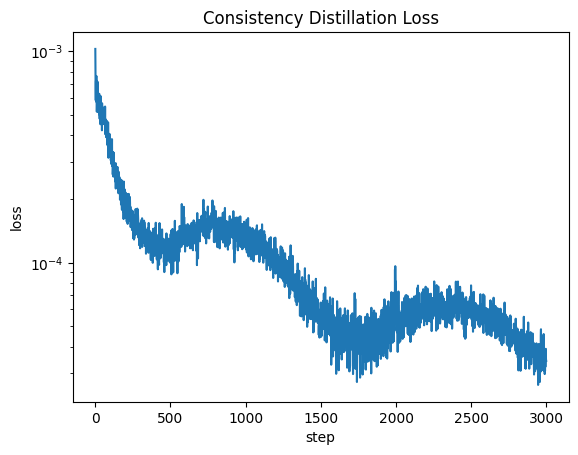

In [3]:
# ===== Consistency Distillation loss =====
# 核心：同一条 ODE 轨迹上相邻两点 (x_t, x_next) 的 student 预测要一致
# 用 EMA target 做一边的预测，防止塌缩
# FM 约定下教师 ODE 从噪声(t=0)流向数据(t=1)，所以教师步是 t 增大方向

@torch.no_grad()
def teacher_step(x, t, dt):
    '''教师沿 ODE 向数据端走一小步（从 t 到 t+dt，dt>0）'''
    v = teacher(x, t)          # 当前点的速度
    return x + dt * v          # Euler 一步，更靠近数据端

opt_s = torch.optim.Adam(student.parameters(), 1e-3)
N = 50  # 离散化时间步数
losses = []

for step in range(3000):
    idx = torch.randperm(1000)[:256]
    x1 = data[idx]; x0 = torch.randn_like(x1)

    # 随机选一对相邻时刻（t_now 靠噪声端，t_next 靠数据端）
    n = torch.randint(0, N - 1, (256,)).float()
    t_now = n / N
    t_next = (n + 1) / N

    # 当前时刻的插值点
    xt = (1-t_now).unsqueeze(-1) * x0 + t_now.unsqueeze(-1) * x1

    # 用教师向数据端走一小步，得到同一条轨迹上 t_next 时刻的点
    x_next = teacher_step(xt, t_now, 1.0 / N)

    # Consistency loss：轨迹上相邻两点预测同一个终点（数据端）
    pred_now = student(xt, t_now)
    with torch.no_grad():
        pred_next = student_ema(x_next, t_next)
    loss = ((pred_now - pred_next)**2).mean()

    opt_s.zero_grad(); loss.backward(); opt_s.step()

    # EMA 更新 target
    with torch.no_grad():
        for p, pe in zip(student.parameters(), student_ema.parameters()):
            pe.copy_(0.95 * pe + 0.05 * p)

    losses.append(loss.item())

plt.plot(losses); plt.yscale('log'); plt.title('Consistency Distillation Loss')
plt.xlabel('step'); plt.ylabel('loss'); plt.show()

/tmp/ipykernel_476520/900789191.py:21: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_476520/900789191.py:21: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_476520/900789191.py:21: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_476520/900789191.py:21: UserWarning: Glyph 25454 (\N{CJK UNIFIED IDEOGRAPH-636E}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_476520/900789191.py:21: UserWarning: Glyph 25945 (\N{CJK UNIFIED IDEOGRAPH-6559}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_476520/900789191.py:21: UserWarning: Glyph 24072 (\N{CJK UNIFIED IDEOGRAPH-5E08}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_4

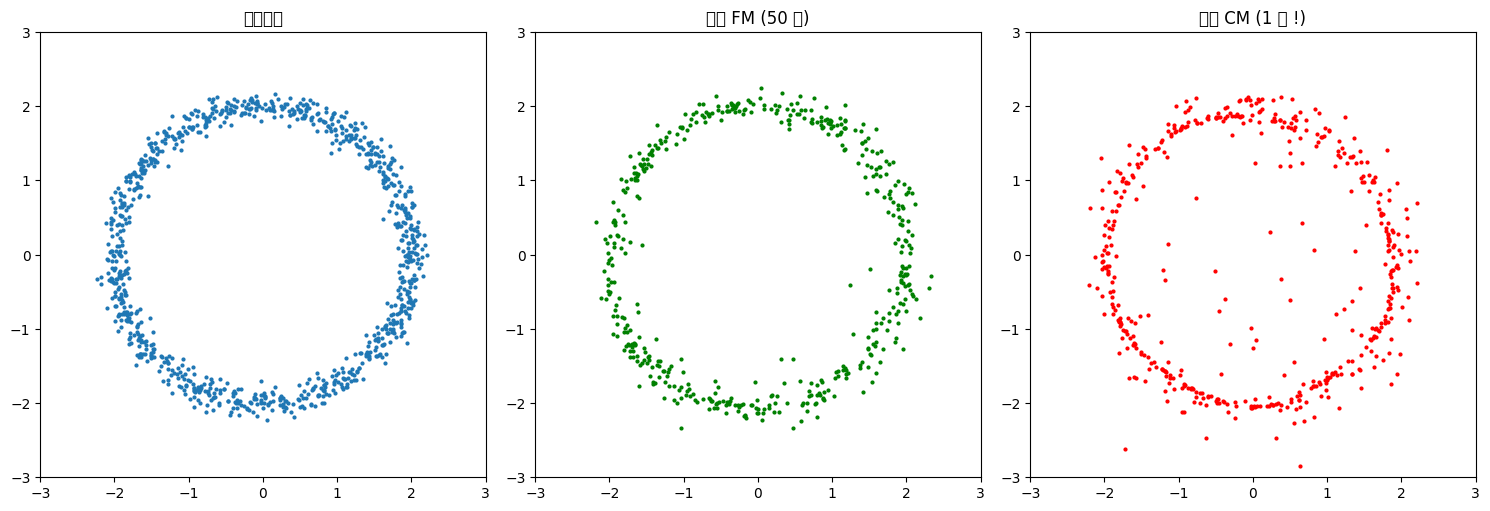

In [4]:
# ===== 对比：1 步 CM 生成 vs 教师 FM 多步生成 =====
@torch.no_grad()
def cm_one_step(n=500):
    x0 = torch.randn(n, 2)          # 纯噪声，位于噪声端
    t0 = torch.zeros(n)             # FM 约定：噪声端是 t=0！
    return student(x0, t0)          # f(noise, 0) 一步跳到数据

@torch.no_grad()
def fm_multistep(n=500, steps=50):
    x = torch.randn(n, 2); dt = 1.0/steps
    for i in range(steps):
        t = torch.full((n,), i*dt)
        x = x + dt * teacher(x, t)
    return x

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].scatter(data[:,0], data[:,1], s=4); axes[0].set_title('真实数据')
axes[1].scatter(*fm_multistep().T, s=4, c='g'); axes[1].set_title('教师 FM (50 步)')
axes[2].scatter(*cm_one_step().T, s=4, c='r'); axes[2].set_title('学生 CM (1 步 !)')
for ax in axes: ax.set_aspect('equal'); ax.set_xlim(-3,3); ax.set_ylim(-3,3)
plt.tight_layout(); plt.show()

## Part 7 — 面试题

**Q1：Consistency Models 的核心训练目标是什么？**
- 相邻时刻的预测要一致（consistency property）：$f(x_t, t) \approx f(x_{t+\Delta t}, t+\Delta t)$。这个约束递推下去保证整条轨迹映射到同一终点，实现 1 步生成。

**Q2：为什么 CM 需要 EMA target network？**
- 如果两边都用同一个网络，loss 很容易塌缩成 $f \equiv \text{constant}$。EMA 固定了其中一边的"标准答案"，防止两端同步塌缩。这和 RL 中的 target Q network 一个原理。

**Q3：边界条件的 $c_{skip}, c_{out}$ 参数化为什么重要？**
- 保证 $f(x_0, 0) = x_0$ 这个"已经在终点不用动"的硬约束自动满足。不加这个，网络要同时学端点不动 + 中间跳到位，训练不稳定。是 CM 论文的核心工程技巧。

**Q4：CM vs DMD 工业选哪个？**
- CM 一步质量与教师有可感知差距（具体数字随任务而异）；DMD 通过分布匹配（score divergence）能更逼近教师质量。注意谱系：**SDXL-Turbo（ADD）/ SD3-Turbo（LADD）/ SDXL-Lightning / FLUX-Schnell 是对抗蒸馏一系，不是 DMD**；DMD/DMD2 是独立的分布匹配路线。CM 是入门理解，对抗蒸馏和 DMD 是两条并行的落地主流。

**Q5：LCM 和 CM 是什么关系？**
- LCM = 在 **latent space** 上做的 CM + **LoRA** 格式封装。核心算法相同，工程打包让 SDXL 老模型 4 行代码升级成 4 步模型。算是 CM 的工业化封装，不是新算法。

**Q6：如果业务要实时数字人 1 步生成，你怎么选型？**
- **Flow Matching + DiT** 训基础模型 → **DMD 蒸馏**到 1 步 → **LoRA 形式** 部署（方便热切换风格）。这是当前最成熟的工业配方。如果预算有限，直接用 FLUX-Schnell / SD3-Turbo 等已蒸馏好的开源 checkpoint。